# Avaliação de Dificuldade (QA Aberto) via LLM Judge

Este notebook estima a **dificuldade empírica** de questões fazendo modelos locais responderem perguntas abertas (QA). Em vez de múltipla escolha, os modelos geram a resposta em texto livre. A avaliação de acerto/erro é feita por um modelo juiz (`llama3.1:8b`).

**Regra de classificação**:
| Nº de modelos que acertam | Dificuldade estimada |
|---|---|
| 3 de 3 | 🟢 Fácil |
| 2 de 3 | 🟡 Média |
| 0 ou 1 de 3 | 🔴 Difícil |

In [15]:
import json
import re
import time
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 120)

In [16]:
# --- Caminhos -----------------------------------------------------------
QUESTOES_PATH = Path("../saida_fase3/repositorio/questoes.jsonl")

OUT_DIR = Path("resultados_dificuldade_qa")
OUT_DIR.mkdir(exist_ok=True)
CHARTS_DIR = OUT_DIR / "graficos"
CHARTS_DIR.mkdir(exist_ok=True)

# Lemos as respostas originais daqui:
CHECKPOINT_PATH_ANTIGO = OUT_DIR / "respostas_qa_ollama.jsonl" 
# Salvamos as novas avaliações aqui:
CHECKPOINT_PATH_NOVO = OUT_DIR / "respostas_qa_ollama_qwen.jsonl" 
RESULTADOS_CSV = OUT_DIR / "resultados_dificuldade_fase3_qa_qwen.csv"

# --- Ollama ---------------------------------------------------------------
OLLAMA_HOST = "http://localhost:11434"

MODELS = [
    "gemma2:2b",
    "phi4-mini:latest",
    "llama3.2:3b",
]

# NOVO MODELO JUIZ
JUDGE_MODEL = "qwen2.5:14b"

TEMPERATURE = 0.0     
NUM_PREDICT_QA = 256    
# O juiz agora precisa de mais tokens para escrever a justificativa antes do veredito
NUM_PREDICT_JUDGE = 512  
TIMEOUT_S = 180        
MAX_RETRIES = 3

SAMPLE_SIZE = None
RANDOM_SEED = 42

# Paletas de cores mantidas...
MODEL_COLORS = {
    "gemma2:2b": "#2a78d6",  
    "phi4-mini:latest": "#eb6834",     
    "llama3.2:3b": "#1baf7a",          
}
DIFF_COLORS = {"Fácil": "#0ca30c", "Média": "#fab219", "Difícil": "#d03b3b"}
DIFF_ORDER = ["Fácil", "Média", "Difícil"]
INK = "#0b0b0b"
INK_MUTED = "#898781"
GRID = "#e1e0d9"

In [17]:
with open(QUESTOES_PATH, encoding="utf-8") as f:
    questoes = [json.loads(l) for l in f if l.strip()]

if SAMPLE_SIZE:
    import random
    random.seed(RANDOM_SEED)
    questoes = random.sample(questoes, min(SAMPLE_SIZE, len(questoes)))

print(f"{len(questoes)} questões carregadas de {QUESTOES_PATH}")

2709 questões carregadas de ../saida_fase3/repositorio/questoes.jsonl


In [18]:
def build_qa_prompt(q: dict) -> str:
    """Monta o prompt de pergunta aberta (QA) sem as alternativas."""
    return (
        "Você é um especialista técnico. Responda à pergunta a seguir de forma direta, clara e concisa, "
        "focando apenas na solução ou conceito solicitado.\n\n"
        f"Pergunta: {q['stem']}\n\n"
        "Resposta:"
    )

def build_judge_prompt(question: str, reference: str, prediction: str) -> str:
    """Monta o prompt para o modelo Juiz avaliar a resposta com Chain of Thought."""
    return (
        "Você é um avaliador técnico especialista, estrito e imparcial.\n"
        "Sua tarefa é avaliar se a 'Resposta do Modelo' resolve a 'Pergunta' da mesma forma "
        "técnica estabelecida na 'Resposta de Referência'.\n\n"
        
        "CRITÉRIOS DE AVALIAÇÃO:\n"
        "1. A resposta do modelo não precisa ter palavras exatas, mas DEVE abordar a mesma estratégia ou conceito central da referência.\n"
        "2. Se a referência propõe uma estratégia de gestão/manutenção (ex: monitoramento, RCM) e o modelo propõe uma alteração física/projeto (ex: trocar peças, instalar amortecedores) que não está na referência, considere INCORRETO.\n"
        "3. Se o modelo incluir alucinações técnicas ou desviar do foco principal da referência, considere INCORRETO.\n\n"
        
        f"Pergunta: {question}\n"
        f"Resposta de Referência: {reference}\n"
        f"Resposta do Modelo: {prediction}\n\n"
        
        "INSTRUÇÕES DE SAÍDA:\n"
        "Primeiro, escreva uma breve justificativa (1 a 3 frases) analisando se a resposta do modelo "
        "se alinha conceitualmente à referência.\n"
        "Depois, em uma nova linha, forneça o seu veredito final no seguinte formato exato: "
        "VEREDITO: CORRETO ou VEREDITO: INCORRETO.\n"
    )

def parse_judge(text: str) -> bool:
    """Interpreta a saída do Juiz buscando o formato 'VEREDITO: ...' de forma tolerante."""
    if not text:
        return False
    
    text_upper = text.strip().upper()
    
    # Busca especificamente o padrão de veredito no final do texto
    match = re.search(r"VEREDITO:\s*(CORRETO|INCORRETO)", text_upper)
    if match:
        return match.group(1) == "CORRETO"
    
    # Fallback caso o modelo fuja um pouco da formatação
    if "INCORRETO" in text_upper:
        return False
    elif "CORRETO" in text_upper:
        return True
    return False

def call_ollama(model: str, prompt: str, num_predict: int) -> str:
    # A função call_ollama se mantém igual à original.
    last_err = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = requests.post(
                f"{OLLAMA_HOST}/api/generate",
                json={
                    "model": model,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": TEMPERATURE, "num_predict": num_predict},
                },
                timeout=TIMEOUT_S,
            )
            r.raise_for_status()
            return r.json().get("response", "")
        except Exception as e:
            last_err = e
            time.sleep(2 * attempt)
    raise RuntimeError(f"Falha ao chamar {model} após {MAX_RETRIES} tentativas: {last_err}")

In [19]:
def checar_ollama():
    try:
        r = requests.get(f"{OLLAMA_HOST}/api/tags", timeout=10)
        r.raise_for_status()
    except Exception as e:
        raise RuntimeError(f"Erro ao acessar Ollama: {e}")
        
    disponiveis = {m["name"] for m in r.json().get("models", [])}
    modelos_necessarios = MODELS + [JUDGE_MODEL]
    faltando = [m for m in modelos_necessarios if m not in disponiveis]
    
    print(f"Ollama OK. Modelos instalados: {sorted(disponiveis)}")
    if faltando:
        comandos = "\n".join(f"  ollama pull {m}" for m in faltando)
        raise RuntimeError("Faltam modelos necessários. Rode:\n" + comandos)
    print("Todos os modelos necessários (incluindo o Juiz) estão disponíveis. ✅")

checar_ollama()

Ollama OK. Modelos instalados: ['gemma2:2b', 'llama3.1:8b', 'llama3.2:3b', 'phi4-mini:latest', 'qwen2.5:14b', 'qwen2.5:7b-instruct']
Todos os modelos necessários (incluindo o Juiz) estão disponíveis. ✅


In [20]:
# def carregar_checkpoint() -> dict:
#     feito = {}
#     if CHECKPOINT_PATH.exists():
#         with open(CHECKPOINT_PATH, encoding="utf-8") as f:
#             for line in f:
#                 line = line.strip()
#                 if line:
#                     rec = json.loads(line)
#                     feito[(rec["id"], rec["model"])] = rec
#     return feito

# feito = carregar_checkpoint()
# print(f"{len(feito)} respostas já registradas no checkpoint.")

# pendentes = [
#     (q, m) for q in questoes for m in MODELS if (q["id"], m) not in feito
# ]
# print(f"{len(pendentes)} avaliações pendentes.")

# with open(CHECKPOINT_PATH, "a", encoding="utf-8") as f_out:
#     for q, model in tqdm(pendentes, desc="Avaliando (Gerador + Juiz)"):
#         # 1. Geração da resposta
#         qa_prompt = build_qa_prompt(q)
#         try:
#             raw_answer = call_ollama(model, qa_prompt, NUM_PREDICT_QA)
#         except RuntimeError as e:
#             print(f"[ERRO QA] {q['id']} / {model}: {e}")
#             continue
            
#         # 2. Avaliação do Juiz (Usamos a alternativa correta como gabarito)
#         reference_answer = q["alternatives"][q["correct_answer_index"]]
#         judge_prompt = build_judge_prompt(q["stem"], reference_answer, raw_answer)
        
#         try:
#             raw_judge = call_ollama(JUDGE_MODEL, judge_prompt, NUM_PREDICT_JUDGE)
#         except RuntimeError as e:
#             print(f"[ERRO JUDGE] {q['id']} / {model}: {e}")
#             continue
            
#         is_correct = parse_judge(raw_judge)
        
#         rec = {
#             "id": q["id"],
#             "model": model,
#             "raw_response": raw_answer,
#             "reference_answer": reference_answer,
#             "judge_response": raw_judge,
#             "correct": is_correct,
#         }
#         f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")
#         f_out.flush()
#         feito[(q["id"], model)] = rec

# print("Avaliação concluída.")

In [21]:
# def classificar_dificuldade(n_corretos: int, n_modelos: int) -> str:
#     if n_corretos == n_modelos:
#         return "Fácil"
#     if n_corretos == n_modelos - 1:
#         return "Média"
#     return "Difícil"

# registros = list(feito.values())
# resp_df = pd.DataFrame(registros)

# pivot_correct = resp_df.pivot_table(
#     index="id", columns="model", values="correct", aggfunc="first"
# )[MODELS]

# n_modelos = len(MODELS)
# n_corretos = pivot_correct.sum(axis=1)
# dificuldade_estimada = n_corretos.apply(lambda n: classificar_dificuldade(n, n_modelos))

# meta = pd.DataFrame(questoes).set_index("id")[
#     ["topico", "subtopico", "difficulty", "nota", "stem"]
# ].rename(columns={"difficulty": "dificuldade_fase3"})

# DIFF_LABEL = {"facil": "Fácil", "media": "Média", "dificil": "Difícil"}
# meta["dificuldade_fase3"] = meta["dificuldade_fase3"].map(DIFF_LABEL).fillna(meta["dificuldade_fase3"])

# resultado = meta.join(pivot_correct).join(
#     n_corretos.rename("n_modelos_corretos")
# ).join(dificuldade_estimada.rename("dificuldade_estimada"))

# resultado["dificuldade_estimada"] = pd.Categorical(
#     resultado["dificuldade_estimada"], categories=DIFF_ORDER, ordered=True
# )

# RESULTADOS_JSON = OUT_DIR / "resultados_dificuldade_fase3_qa.json"

# resultado.to_json(RESULTADOS_JSON)
# print(f"Resultado consolidado salvo em {RESULTADOS_JSON}")
# resultado.head()

In [22]:
# 1. Carrega o checkpoint ANTIGO apenas para pegar as respostas que os modelos já escreveram
respostas_geradas = {}
if CHECKPOINT_PATH_ANTIGO.exists():
    with open(CHECKPOINT_PATH_ANTIGO, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                # Salva a resposta crua usando (id_da_questao, modelo) como chave
                respostas_geradas[(rec["id"], rec["model"])] = rec["raw_response"]

# 2. Carrega o checkpoint NOVO para ver se a execução atual já fez progresso (para resumir em caso de queda)
feito = {}
if CHECKPOINT_PATH_NOVO.exists():
    with open(CHECKPOINT_PATH_NOVO, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                feito[(rec["id"], rec["model"])] = rec

print(f"{len(respostas_geradas)} respostas encontradas no log antigo.")
print(f"{len(feito)} avaliações já feitas pelo novo juiz.")

pendentes = [
    (q, m) for q in questoes for m in MODELS if (q["id"], m) not in feito
]
print(f"{len(pendentes)} avaliações pendentes para o juiz {JUDGE_MODEL}.")

with open(CHECKPOINT_PATH_NOVO, "a", encoding="utf-8") as f_out:
    for q, model in tqdm(pendentes, desc="Avaliando (Apenas Juiz)"):
        
        # Recupera a resposta que o modelo gerou na execução anterior
        raw_answer = respostas_geradas.get((q["id"], model))
        if not raw_answer:
            print(f"Aviso: Nenhuma resposta anterior encontrada para {q['id']} / {model}. Pulando.")
            continue
            
        # Avaliação do NOVO Juiz
        reference_answer = q["alternatives"][q["correct_answer_index"]]
        judge_prompt = build_judge_prompt(q["stem"], reference_answer, raw_answer)
        
        try:
            raw_judge = call_ollama(JUDGE_MODEL, judge_prompt, NUM_PREDICT_JUDGE)
        except RuntimeError as e:
            print(f"[ERRO JUDGE] {q['id']} / {model}: {e}")
            continue
            
        is_correct = parse_judge(raw_judge)
        
        rec = {
            "id": q["id"],
            "model": model,
            "raw_response": raw_answer, # Mantemos a resposta gerada original
            "reference_answer": reference_answer,
            "judge_response": raw_judge, # Aqui vai ficar salvo o raciocínio + VEREDITO do Qwen
            "correct": is_correct,
        }
        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")
        f_out.flush()
        feito[(q["id"], model)] = rec

print("Nova avaliação concluída.")

8127 respostas encontradas no log antigo.
0 avaliações já feitas pelo novo juiz.
8127 avaliações pendentes para o juiz qwen2.5:14b.


Avaliando (Apenas Juiz):   0%|          | 0/8127 [00:00<?, ?it/s]

Nova avaliação concluída.


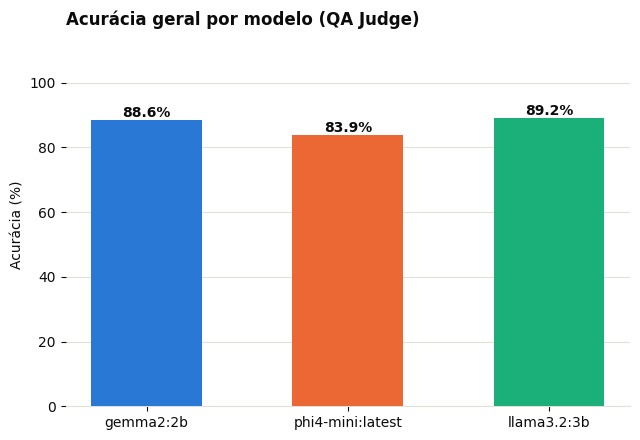

In [23]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

def limpar_eixos(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    
acc_geral = resultado[MODELS].mean().reindex(MODELS) * 100

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(
    range(len(MODELS)), acc_geral.values,
    color=[MODEL_COLORS[m] for m in MODELS], width=0.55, zorder=3,
)
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(MODELS, rotation=0)
ax.set_ylim(0, 112)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_ylabel("Acurácia (%)")
ax.set_title(f"Acurácia geral por modelo (QA Judge)", loc="left", fontweight="bold", pad=14)
limpar_eixos(ax)
for b, v in zip(bars, acc_geral.values):
    ax.annotate(f"{v:.1f}%", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                fontsize=10, color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

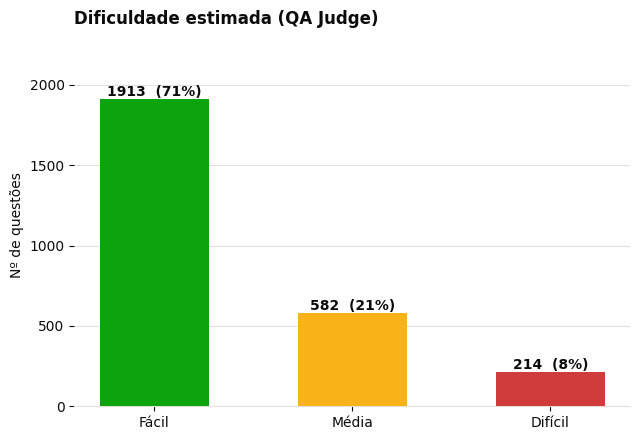

In [11]:
contagem_dif = resultado["dificuldade_estimada"].value_counts().reindex(DIFF_ORDER).fillna(0)
pct_dif = contagem_dif / contagem_dif.sum() * 100

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(DIFF_ORDER, contagem_dif.values, color=[DIFF_COLORS[d] for d in DIFF_ORDER], width=0.55, zorder=3)
ax.set_ylim(0, max(contagem_dif.values.max(), 1) * 1.18)
ax.set_ylabel("Nº de questões")
ax.set_title("Dificuldade estimada (QA Judge)", loc="left", fontweight="bold", pad=14)
limpar_eixos(ax)
for b, v, p in zip(bars, contagem_dif.values, pct_dif.values):
    ax.annotate(f"{int(v)}  ({p:.0f}%)", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                fontsize=10, color=INK, fontweight="bold")
fig.tight_layout()
plt.show()